# Module 6 — Engagement: DAU/MAU Stickiness *(recap)*

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

DAU/MAU stickiness is covered in the A/B Testing Playbook. This module is a short recap: the definition, what that playbook's notebook `02_b2c_product_metrics.ipynb` showed (with its printed numbers and link), and the real ratio on this playbook's store data, under two definitions of "active".

## From the curriculum

> ## <u>Module 6 — Engagement: DAU/MAU Stickiness</u> *(recap)*
>
> **Covered in:** A/B Testing Playbook,
> [`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb),
> "Part 3 — DAU/MAU stickiness" (simulated).
>
> **Recap:** DAU (Daily Active Users) / MAU (Monthly Active Users) as "how many
> days a month the average monthly user shows up"; "active" depends on the
> definition (Module 1).
>
> **Compact recompute:** real DAU/MAU over five months, under two definitions of
> "active".

Note on the quote above: strictly, DAU/MAU is a share; multiplied by the days in the month it gives "how many days a month the average monthly user shows up" (see the formula below).

## Recap

**Definitions:**
- **DAU** (Daily Active Users) = users active on a given day. **MAU** (Monthly Active Users) = users active at least once in a given month.
- **Stickiness** = average DAU ÷ MAU, for the same month. It answers: of the people who use the product in a month, what share use it on a typical day?
- What counts as **active** is a definition (Module 1): any event, or only a meaningful action. The ratio can change with it (here it barely does, see below).
- **Active days per active user** = the average number of days in the month on which a user active that month had any event. This is Module 2's HEART Engagement metric.

**The formula, step by step:**
- average DAU × days in the month = total user-days in the month (each user counted once for each day they were active);
- total user-days ÷ MAU = active days per active user;
- so (average DAU ÷ MAU) × days in the month = active days per active user, exactly.

### What the A/B Testing Playbook showed

[`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb), section "Part 3 — DAU/MAU stickiness". Simulated data: an installed base (everyone who ever signed up) of 20,000 users, 75% of whom had stopped using the product. Numbers quoted from its printed output:
- DAU (day 30): 7.3% of the installed base
- MAU (days 1–30): 24.4% of the installed base
- stickiness (DAU/MAU): 29.8%

Its main point, in its own words: "DAU/MAU is a *base-mix* metric — it depends as much on how much of your all-time signup base has churned out entirely as it does on how engaged your remaining active users are."

Note: there, DAU is a single day (day 30), not a monthly average as here, so the 29.8% is only a rough reference point.

## Compact recompute: DAU/MAU by month on this store's data

**Definitions:**
- One row per calendar month, October 2019 to February 2020.
- **Average DAU** = the average, over the days of the month, of users active that day. **MAU** = users active at least once that month.
- Two definitions of **active**:
  - **A, any event:** a view, cart add, cart removal or purchase;
  - **B, cart or purchase:** only a cart add or a purchase (browsing alone doesn't count).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from common import connect, query, show, BLUE, ORANGE

con = connect()
ev = query(con, "SELECT DISTINCT user_id, event_date, event_month, event_type IN ('cart', 'purchase') AS cart_or_purchase FROM events_clean")

def monthly(d):
    ud = d[["user_id", "event_date", "event_month"]].drop_duplicates()
    dau = ud.groupby(["event_month", "event_date"]).size().groupby("event_month").mean()
    mau = ud.groupby("event_month")["user_id"].nunique()
    days = ud.groupby("event_month")["event_date"].nunique()
    return pd.DataFrame({"dau": dau, "mau": mau, "days": days, "stickiness": dau / mau * 100, "days_per_user": dau * days / mau})

a = monthly(ev)
b = monthly(ev[ev["cart_or_purchase"] == 1])
show(pd.DataFrame({
    "month": a.index,
    "A: avg DAU": a["dau"].map("{:,.1f}".format).values,
    "A: MAU": a["mau"].map("{:,}".format).values,
    "A: DAU/MAU %": a["stickiness"].map("{:.2f}".format).values,
    "B: avg DAU": b["dau"].map("{:,.1f}".format).values,
    "B: MAU": b["mau"].map("{:,}".format).values,
    "B: DAU/MAU %": b["stickiness"].map("{:.2f}".format).values,
}))
print()
show(pd.DataFrame({
    "month": a.index,
    "B MAU as % of A MAU": (b["mau"] / a["mau"] * 100).map("{:.2f}".format).values,
    "B minus A, DAU/MAU points": (b["stickiness"] - a["stickiness"]).map("{:+.2f}".format).values,
}))

month    A: avg DAU  A: MAU  A: DAU/MAU %  B: avg DAU  B: MAU  B: DAU/MAU %
2019-10     1,802.6  40,098          4.50       594.5  13,478          4.41
2019-11     1,832.3  36,857          4.97       505.0   9,556          5.28
2019-12     1,708.3  37,167          4.60       400.1   8,378          4.78
2020-01     1,929.9  41,105          4.70       467.1   9,279          5.03
2020-02     1,968.0  38,943          5.05       481.1   8,880          5.42

month    B MAU as % of A MAU  B minus A, DAU/MAU points
2019-10                33.61                      -0.08
2019-11                25.93                      +0.31
2019-12                22.54                      +0.18
2020-01                22.57                      +0.34
2020-02                22.80                      +0.36


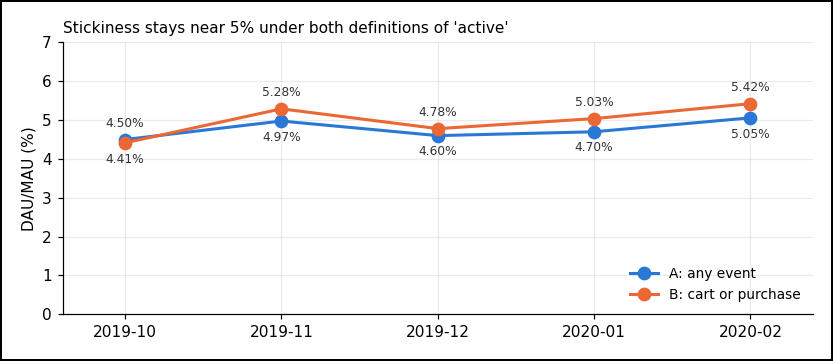

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
x = range(len(a))
for d, color, label in [(a, BLUE, "A: any event"), (b, ORANGE, "B: cart or purchase")]:
    ax.plot(x, d["stickiness"], marker="o", markersize=8, linewidth=2, color=color, label=label)
for xi, va_, vb_ in zip(x, a["stickiness"], b["stickiness"]):
    for v, other in ((va_, vb_), (vb_, va_)):   # the higher value's label goes above, the lower one's below
        above = v >= other
        ax.text(xi, v + (0.25 if above else -0.25), f"{v:.2f}%", ha="center", va="bottom" if above else "top", fontsize=8, color="#333333")
ax.set_xticks(list(x), a.index)
ax.set_xlim(-0.4, len(a) - 0.6)
ax.set_ylim(0, 7)
ax.set_ylabel("DAU/MAU (%)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Stickiness stays near 5% under both definitions of 'active'", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** under definition A, DAU/MAU is 4.50% to 5.05% by month. On a typical day, about 1 in 20 of the month's active users is active (100 ÷ 5 = 20).

**Observation:** definition B has far fewer users: B's MAU is 22.54% to 33.61% of A's. But its ratio stays close to A's: within −0.08 to +0.36 points each month. Stickiness measures how often the month's users come, not how many there are.

**Observation:** the store's stickiness (about 5%) is far below the A/B simulation's 29.8%. The two are different data (a simulated, frequently used product vs. this store) and use a different DAU method, so the 29.8% is only a reference for what a frequently used product looks like, not a like-for-like comparison.

**Hypothesis:** people shop here only when they need something, unlike the frequently used product that simulation was built to mimic. Not tested here.

**The formula in numbers** (November, definition A):

In [3]:
nov = a.loc["2019-11"]
print(f"average DAU x days = {nov['dau']:,.1f} x {int(nov['days'])} = {nov['dau'] * nov['days']:,.0f} user-days")
print(f"user-days / MAU    = {nov['dau'] * nov['days']:,.0f} / {int(nov['mau']):,} = {nov['days_per_user']:.3f} active days per active user")
print(f"check: DAU/MAU x days = {nov['stickiness']:.2f}% x {int(nov['days'])} = {nov['stickiness'] / 100 * nov['days']:.3f}")
print()
show(pd.DataFrame({"month": a.index, "days": a["days"].values,
                   "A: DAU/MAU %": a["stickiness"].map("{:.2f}".format).values,
                   "A: active days per active user": a["days_per_user"].map("{:.3f}".format).values}))
jan, feb = a.loc["2020-01"], a.loc["2020-02"]
print(f"\nJanuary -> February: DAU/MAU {(feb['stickiness'] / jan['stickiness'] - 1):+.2%}, "
      f"active days per active user {(feb['days_per_user'] / jan['days_per_user'] - 1):+.2%}")

average DAU x days = 1,832.3 x 30 = 54,970 user-days
user-days / MAU    = 54,970 / 36,857 = 1.491 active days per active user
check: DAU/MAU x days = 4.97% x 30 = 1.491

month    days  A: DAU/MAU %  A: active days per active user
2019-10    31          4.50                           1.394
2019-11    30          4.97                           1.491
2019-12    31          4.60                           1.425
2020-01    31          4.70                           1.455
2020-02    29          5.05                           1.466

January -> February: DAU/MAU +7.63%, active days per active user +0.69%


**Observation:** an active user is active on 1.394 to 1.491 days a month (definition A). These are exactly Module 2's Engagement numbers (Part 2, HEART): the same quantity, reached through DAU/MAU.

**Observation:** month length matters. Because DAU/MAU = active days per active user ÷ days in the month, a 29-day month raises DAU/MAU even if behaviour doesn't change. From January (31 days) to February (29 days), DAU/MAU rises by 7.63%, but active days per active user only by 0.69%: most of February's higher DAU/MAU is the shorter month.

**Conclusion:** DAU/MAU and active days per active user carry the same information, but active days per active user is easier to read and fairer to compare across months of different lengths. Whichever definition of "active" is used, it should be stated next to the number (Module 1).

## Key takeaways

- **Recap:** DAU/MAU depends on who is in the base (A/B Testing Playbook, `02_b2c_product_metrics.ipynb`).
- **Observation:** on this store, DAU/MAU is about 5% by month (4.50% to 5.05%, any event), far below the A/B simulation's 29.8%.
- **Observation:** counting only cart adds and purchases leaves 22.54% to 33.61% of the monthly users, but the ratio stays within 0.36 points of the any-event one.
- **Conclusion:** DAU/MAU × days in the month = active days per active user (1.394 to 1.491 here). Compare months on active days per active user, since DAU/MAU rises in short months; and state the definition of "active" with the number.